# HS4002 Week 2

## Setup

Make sure this notebook and `gss2022_mini.csv` are in the same folder. Install packages below if needed.

In [1]:
# !pip install pandas numpy plotnine

import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')

# Python Fundamentals

Before working with real survey data, it's worth getting comfortable with the building blocks every Python program is made of: variables, strings, lists, dictionaries, conditionals, loops, and functions. Each of these will show up again, in a pandas-flavoured form, later in this notebook.

## Variables and Data Types

Create three variables: your name (a `str`), your age (an `int`), and your height in meters (a `float`). Print each one alongside its data type.

Hint: `type(some_variable)` tells you what data type something is.

In [2]:
name = "Jamie"
age = 20
height = 1.68

print(name, type(name))

Jamie <class 'str'>


In [4]:
age*12

240

In [5]:
name + name

'JamieJamie'

## Conditionals (if / elif / else)

Write a conditional that decides whether a respondent counts as a "minor", "young adult", or "adult" based on their age.

Hint: Python uses `if`, `elif`, `else` — and indentation (not curly braces) marks what belongs inside each branch.

In [6]:
respondent_age = 17

if respondent_age < 18: 
    category = "minor"
elif respondent_age < 21:
    category = "young adult"
else:
    category = "adult"

print(category)

minor


## Functions

Wrap the minor / young adult / adult logic from earlier into a reusable **function**, then apply it to every age in `ages`.

Hint: `def function_name(parameter):` starts a function; `return` sends a value back to whoever called it.

In [7]:
def categorize_age(age_input):
    if age_input < 18:
        return "minor"
    elif age_input  < 30:
        return "young adult"
    else:
        return "adult"

categorize_age(25)

'young adult'

## Objects, Attributes, and Methods

Everything in Python is an **object** — including the DataFrames you're about to work with. An object bundles together data (**attributes**, accessed with `object.attribute`, no parentheses) and behavior (**methods**, accessed with `object.method()`, always with parentheses — even if empty).

You'll see this pattern constantly for the rest of this notebook: `df.shape` and `df.columns` are attributes; `df.dropna()` and `df.sample()` are methods.

In [8]:
example_list = [3, 1, 2]

print(len(example_list))     # a function, not a method
example_list.sort()          # a method -- changes the list in place
print(example_list)

example_str = "hello"
print(example_str.upper())   # another method, even on a plain string

3
[1, 2, 3]
HELLO


## Reading the Data

Hint: use `pd.read_csv()`. The data object in pandas is called a **DataFrame**.

In [12]:
# reads the file
df = pd.read_csv("gss2022_mini.csv")

In [15]:
df.tail()

,year,id,wrkstat,occ10,prestg10,marital,educ,age,degree,major1,...,cvdmov,cvdcreat,cvdrdg,cvdtour,cvdstmus,cvdarmus,cvdstpo,cvdarpo,cvdclass,cvdpod
3539,2022,3541,1.0,5300.0,30.0,5.0,12.0,22.0,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3540,2022,3542,1.0,2310.0,61.0,1.0,19.0,29.0,4,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3541,2022,3543,1.0,3220.0,62.0,5.0,15.0,32.0,2,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3542,2022,3544,1.0,2310.0,61.0,1.0,17.0,49.0,4,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3543,2022,3545,1.0,6120.0,42.0,1.0,20.0,50.0,4,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## How many rows does the file contain?

Hint: `len(df)` or `df.shape[0]`.

In [16]:
df.shape

(3544, 49)

## Print the names of all columns

In [17]:
df.columns

Index(['year', 'id', 'wrkstat', 'occ10', 'prestg10', 'marital', 'educ', 'age',
       'degree', 'major1', 'biokids', 'sex', 'race', 'income16', 'rincom16',
       'pres16', 'pres20', 'happy', 'health', 'natspac', 'natenvir', 'natheal',
       'natcrime', 'reg16', 'yrlvmus', 'yrartxbt', 'yrmovie', 'artsout',
       'yrcreat', 'yrrdg', 'yrtour', 'yrstmus', 'yrarmus', 'yrstpo', 'yrarpo',
       'yrclass', 'yrpod', 'cvdlvmus', 'cvdart', 'cvdmov', 'cvdcreat',
       'cvdrdg', 'cvdtour', 'cvdstmus', 'cvdarmus', 'cvdstpo', 'cvdarpo',
       'cvdclass', 'cvdpod'],
      dtype='object')

# Selecting and Sampling

Narrow the dataset down to five variables: survey ID (`id`), employment status (`wrkstat`), occupational prestige (`prestg10`), age (`age`), and gender (`sex`).

Hint: index the DataFrame with a list of column names.

In [20]:
chosen_variables = ["id", "wrkstat", "prestg10", "age", "sex"]

df_small = df.loc[:, chosen_variables]

In [24]:
df_small_50plus = df_small.loc[df_small["age"] >= 50, :]
df_small_50plus

,id,wrkstat,prestg10,age,sex
0,1,1.0,39.0,72.0,2.0
1,2,5.0,53.0,80.0,1.0
2,3,1.0,48.0,57.0,2.0
4,5,8.0,38.0,62.0,1.0
9,10,5.0,48.0,72.0,2.0
...,...,...,...,...,...
3535,3537,5.0,61.0,66.0,1.0
3536,3538,5.0,73.0,78.0,1.0
3537,3539,5.0,33.0,73.0,1.0
3538,3540,5.0,27.0,84.0,2.0


## Checking for Missing Data First

Before dropping any rows, it's worth seeing *how much* is actually missing, and in which columns — dropping blindly can silently throw away more data than you realize.

Hint: `.isna()` marks each cell `True`/`False` for missing; `.sum()` on top of that counts how many `True`s per column.

In [25]:
print(df_small.isna().sum())

id            0
wrkstat       7
prestg10    218
age         208
sex          20
dtype: int64


## Dropping rows with missing values

Hint: use `.dropna()`.

In [26]:
df2 = df_small.dropna()

## Taking a sample of 500

Setting a random seed makes the sample reproducible.

Hint: use `.sample(n=..., random_state=...)`.

In [30]:
df_mini = df2.sample(n=500, random_state=47)
df_mini

,id,wrkstat,prestg10,age,sex
218,219,5.0,41.0,44.0,1.0
1653,1654,1.0,38.0,41.0,2.0
3487,3489,5.0,64.0,64.0,1.0
363,364,5.0,35.0,70.0,1.0
3366,3367,1.0,66.0,35.0,1.0
...,...,...,...,...,...
1457,1458,4.0,31.0,43.0,2.0
821,822,1.0,38.0,65.0,1.0
1910,1911,5.0,35.0,69.0,2.0
1309,1310,5.0,61.0,72.0,2.0


## Sanity check — should be 500 rows and 5 columns

In [28]:
print(df_mini.shape)

(500, 5)


## Saving Your Cleaned Data

Write `df_mini` out to a new file, so you (or someone else) can pick up from here without re-running everything above.

Hint: `.to_csv(..., index=False)`. Name the output differently from the input, so you don't overwrite your source data.

In [31]:
# df_mini.to_csv("gss2022_mini_cleaned.csv", index=False)

# Making New Variables

Recode `wrkstat` into a working/not-working binary. Full-time (1), part-time (2), and with-a-job-but-not-at-work (3) are all counted as working.

Hint: `np.where(condition, if_true, if_false)` lets you recode based on a condition.

In [32]:
df_mini = df_mini.assign(
    working  = np.where(df_mini['wrkstat'] <= 3, 'Working', 'Not Working'),
    sex_woman = np.where(df_mini['sex'] == 2, 'Woman', 'Not Woman')
)

## Sanity check — print the breakdown of each new variable

In [33]:
print(df_mini['working'].value_counts())
print(df_mini['sex_woman'].value_counts())

working
Working        292
Not Working    208
Name: count, dtype: int64
sex_woman
Woman        258
Not Woman    242
Name: count, dtype: int64


## Casting a Column's Type

Sometimes you need to change a column's *type* without changing its values — different from recoding, which is what `sex_woman` did above.

Hint: `.astype(str)` casts a column to text.

In [34]:
df_mini['sex_str'] = df_mini['sex'].astype(str)
print(df_mini['sex_str'].dtype)

object


# Producing a Table

We want the mean occupational prestige among working men and women.

## Filter for working individuals

Hint: use boolean indexing.

In [35]:
df_wrk = df_mini.loc[df_mini['working'] == 'Working',:]

## Filtering on More Than One Condition

Narrow `df_mini` down to just the working women.

Hint: combining conditions in pandas uses `&` (and) / `|` (or) — not Python's plain `and`/`or` — and each condition needs its own parentheses.

In [36]:
df_working_women = df_mini[
    (df_mini['working'] == 'Working') & (df_mini['sex_woman'] == 'Woman')
]
print(df_working_women.shape)

(147, 8)


## Mean occupational prestige by gender

We'll do it the long way — split into two dataframes first (useful for learning), then retrieve the mean of each.

In [37]:
df_men   = df_wrk[df_wrk['sex_woman'] == 'Not Woman']
df_women = df_wrk[df_wrk['sex_woman'] == 'Woman']

print(df_men['prestg10'].mean())
print(df_women['prestg10'].mean())

45.86896551724138
45.74149659863946


## Building a summary table

In [38]:
first_table = pd.DataFrame({
    'gender':          ['Men', 'Women'],
    'mean_occ_prestg': [df_men['prestg10'].mean(), df_women['prestg10'].mean()]
})
first_table

,gender,mean_occ_prestg
0,Men,45.868966
1,Women,45.741497


## Exporting Your Table for Use in Word

pandas can save your table as a CSV file. A CSV stores table data in a format that Excel and Google Sheets can easily open.

After running the next cell:

1. Find the new CSV file in the same folder as this notebook.
2. Open it in Excel or import it into Google Sheets.
3. Select and copy the table.
4. Paste the table into your Word document.

Opening the CSV directly in Word is not recommended because Word may show it as plain, comma-separated text.

Hint: `.to_csv(..., index=False)` prevents pandas from adding an unnecessary column of row numbers.

In [39]:
first_table.to_csv(
    "mean_occupational_prestige_by_gender.csv",
    index=False,
    float_format="%.1f"
)

In [40]:
# Optional: export the table as LaTeX code for a LaTeX document
print(first_table.to_latex(
    index=False,
    float_format="%.1f",
    caption="Mean Occupational Prestige by Gender",
    header=["Gender", "Mean Occupational Prestige"]
))

\begin{table}
\caption{Mean Occupational Prestige by Gender}
\begin{tabular}{lr}
\toprule
Gender & Mean Occupational Prestige \\
\midrule
Men & 45.9 \\
Women & 45.7 \\
\bottomrule
\end{tabular}
\end{table}



# Making a Scatterplot

Plot the relationship between age and occupational prestige, coloured by gender.

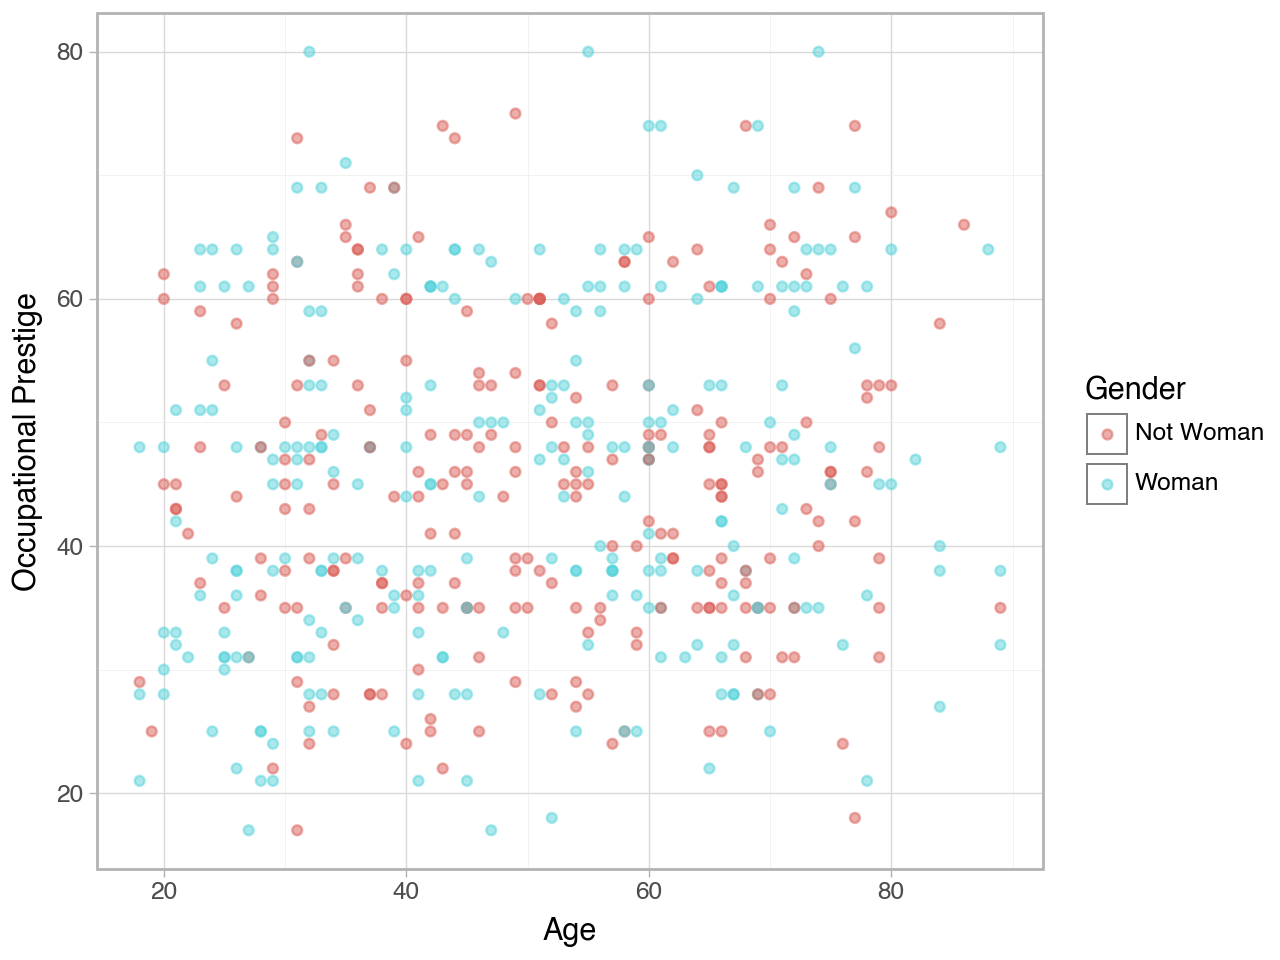

In [41]:
(
    p9.ggplot(df_mini) +
    p9.geom_point(p9.aes(x='age', y='prestg10', color='sex_woman'), alpha=0.5) +
    p9.theme_light() +
    p9.labs(x='Age', y='Occupational Prestige', color='Gender')
)